# Projet My Content : exploration des données

## Chargement

In [1]:
import sys
import warnings

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import utils

warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)


def fmt(n):
    return f"{n:,}".replace(",", " ")


clicks = utils.load_clicks("../data")
articles = utils.load_articles_metadata("../data")
embeddings = utils.load_embeddings("../data")
clicks.head()

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,59,1506826329267796,1506826329000,2,234853,1506826800026,4,3,2,1,21,1
1,79,1506826486139816,1506826486000,2,159359,1506826801702,4,3,2,1,13,1
2,154,1506826793323891,1506826793000,2,96663,1506826804207,4,3,2,1,25,7
3,111,1506826621773848,1506826621000,2,202436,1506826814140,4,3,2,1,9,7
4,70,1506826416120807,1506826416000,3,119592,1506826818863,4,3,2,1,13,2


## Chiffres clés

In [2]:
n_clics = len(clicks)
n_users = clicks["user_id"].nunique()
n_articles = clicks["click_article_id"].nunique()

print("Clics :", fmt(n_clics))
print("Utilisateurs :", fmt(n_users))
print("Articles cliqués :", fmt(n_articles), "sur", fmt(len(articles)), "au catalogue")
print("Première date :", pd.to_datetime(clicks["click_timestamp"].min(), unit="ms"))
print("Dernière date :", pd.to_datetime(clicks["click_timestamp"].max(), unit="ms"))

Clics : 2 988 181
Utilisateurs : 322 897
Articles cliqués : 46 033 sur 364 047 au catalogue
Première date : 2017-10-01 03:00:00.026000
Dernière date : 2017-11-13 20:04:14.886000


## Clics par utilisateur

Médiane : 4.0 clics
Moyenne : 9.3 clics
Utilisateurs avec 2 clics ou moins : 31%


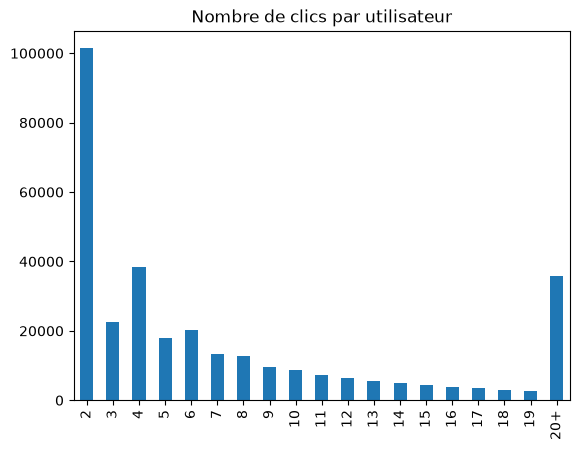

In [3]:
clics_par_user = clicks.groupby("user_id").size()

print("Médiane :", clics_par_user.median(), "clics")
print("Moyenne :", round(clics_par_user.mean(), 1), "clics")
print(f"Utilisateurs avec 2 clics ou moins : {(clics_par_user <= 2).mean():.0%}")

distribution = clics_par_user.clip(upper=20).value_counts().sort_index()
distribution.index = [str(i) if i < 20 else "20+" for i in distribution.index]
distribution.plot.bar(title="Nombre de clics par utilisateur")
plt.show()

## Sessions

La durée du premier au dernier clic est peu fiable : les clics d'une session sont souvent espacés artificiellement de 30 s.

Sessions : 1 048 594
Médiane : 2.0 clics par session
Moyenne : 2.8 clics par session
Durée médiane du premier au dernier clic : 0.5 minutes


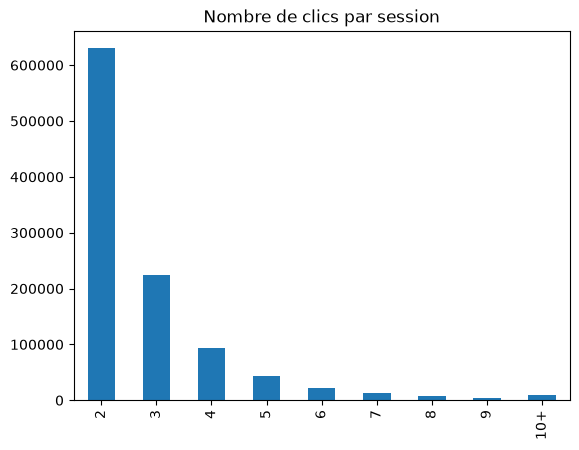

In [4]:
sessions = clicks.groupby("session_id")["click_timestamp"].agg(["size", "min", "max"])
duree = (sessions["max"] - sessions["min"]) / 60_000

print("Sessions :", fmt(len(sessions)))
print("Médiane :", sessions["size"].median(), "clics par session")
print("Moyenne :", round(sessions["size"].mean(), 1), "clics par session")
print("Durée médiane du premier au dernier clic :", round(duree.median(), 1), "minutes")

distribution = sessions["size"].clip(upper=10).value_counts().sort_index()
distribution.index = [str(i) if i < 10 else "10+" for i in distribution.index]
distribution.plot.bar(title="Nombre de clics par session")
plt.show()

## Temps de lecture

Le dataset n'a pas de temps de lecture : on regarde l'écart entre deux clics consécutifs d'une même session. On garde donc le clic seul (1 = lu), sans pondération par une durée.

In [5]:
ordre = clicks.sort_values(["session_id", "click_timestamp"])
ecarts = np.diff(ordre["click_timestamp"].values) / 1000
meme_session = ordre["session_id"].values[1:] == ordre["session_id"].values[:-1]
ecarts = ecarts[meme_session]

print("Écart médian entre deux clics d'une session :", np.median(ecarts), "secondes")
print(f"Écarts valant exactement 30 s : {(ecarts == 30).mean():.0%}")

Écart médian entre deux clics d'une session : 30.0 secondes
Écarts valant exactement 30 s : 54%


## Popularité des articles : longue traîne

993 articles (2.2% des articles cliqués) font 80 % des clics


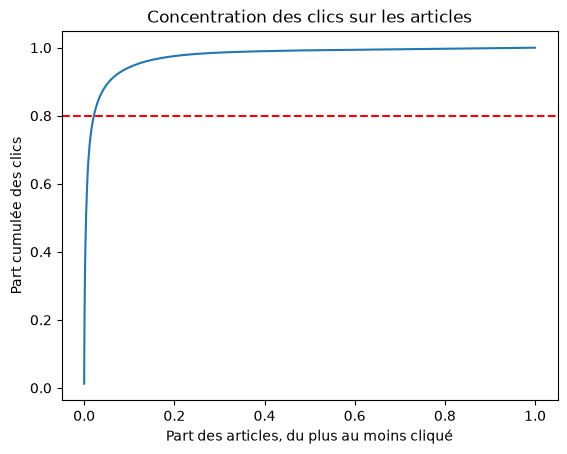

click_article_id
160974    37213
272143    28943
336221    23851
234698    23499
123909    23122
336223    21855
96210     21577
162655    21062
183176    20303
168623    19526
Name: count, dtype: int64

In [6]:
popularite = clicks["click_article_id"].value_counts()
part_cumulee = popularite.cumsum() / n_clics
n_80 = (part_cumulee < 0.8).sum() + 1

print(f"{fmt(n_80)} articles ({n_80 / n_articles:.1%} des articles cliqués) font 80 % des clics")
plt.plot(np.arange(1, len(popularite) + 1) / len(popularite), part_cumulee.values)
plt.axhline(0.8, color="red", linestyle="--")
plt.title("Concentration des clics sur les articles")
plt.xlabel("Part des articles, du plus au moins cliqué")
plt.ylabel("Part cumulée des clics")
plt.show()
popularite.head(10)

## Taux de remplissage de la matrice utilisateurs x articles

In [7]:
n_paires = len(clicks[["user_id", "click_article_id"]].drop_duplicates())
remplissage = n_paires / (n_users * n_articles)

print(f"Cases remplies : {remplissage:.3%}")

Cases remplies : 0.020%


## Embeddings

In [8]:
print("Taille :", embeddings.shape)
print("Mémoire :", round(embeddings.nbytes / 1e6), "Mo")

Taille : (364047, 250)
Mémoire : 364 Mo


## Similarité entre articles

Similarité moyenne : 0.60 dans la même catégorie, 0.19 entre catégories différentes


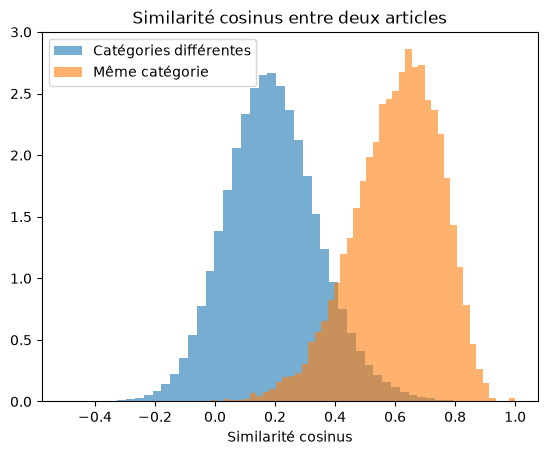

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

extrait = articles.sample(2000, random_state=12)
paires = np.triu_indices(2000, 1)
sim = cosine_similarity(embeddings[extrait["article_id"]])[paires]
meme = np.equal.outer(extrait["category_id"].values, extrait["category_id"].values)[paires]

print(f"Similarité moyenne : {sim[meme].mean():.2f} dans la même catégorie, {sim[~meme].mean():.2f} entre catégories différentes")
plt.hist(sim[~meme], bins=50, density=True, alpha=0.6, label="Catégories différentes")
plt.hist(sim[meme], bins=50, density=True, alpha=0.6, label="Même catégorie")
plt.title("Similarité cosinus entre deux articles")
plt.xlabel("Similarité cosinus")
plt.legend()
plt.show()

## Projection t-SNE

Articles projetés : 4 000


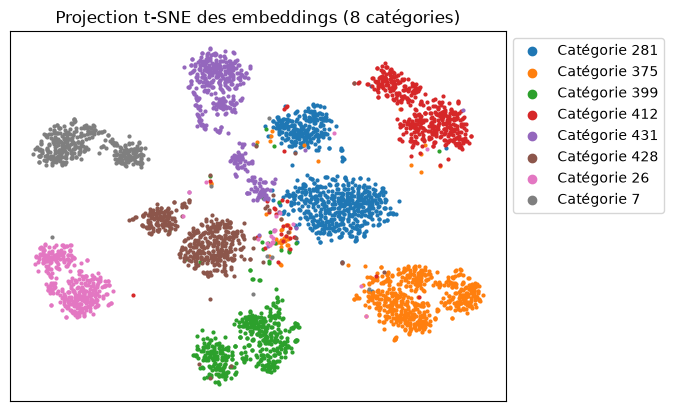

In [10]:
from sklearn.manifold import TSNE

categories = articles["category_id"].value_counts().head(8).index
tires = articles[articles["category_id"].isin(categories)].sample(4000, random_state=12)
projection = TSNE(n_components=2, init="pca", random_state=12).fit_transform(embeddings[tires["article_id"]])

print("Articles projetés :", fmt(len(tires)))
for categorie in categories:
    masque = (tires["category_id"] == categorie).values
    plt.scatter(projection[masque, 0], projection[masque, 1], s=4, label=f"Catégorie {categorie}")
plt.title("Projection t-SNE des embeddings (8 catégories)")
plt.xticks([])
plt.yticks([])
plt.legend(markerscale=3, bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

## Réduction de dimension (PCA)

Variance conservée avec 50 dimensions sur 250 : 94.5%


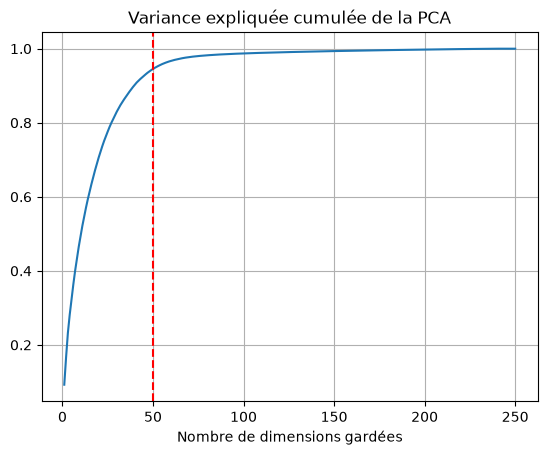

In [11]:
from sklearn.decomposition import PCA

echantillon = embeddings[np.random.default_rng(12).choice(len(embeddings), 50_000, replace=False)]
variance = pd.Series(PCA(random_state=12).fit(echantillon).explained_variance_ratio_.cumsum(), index=range(1, 251))

print(f"Variance conservée avec 50 dimensions sur 250 : {variance[50]:.1%}")
variance.plot(title="Variance expliquée cumulée de la PCA", xlabel="Nombre de dimensions gardées", grid=True)
plt.axvline(50, color="red", linestyle="--")
plt.show()

## Clics par jour

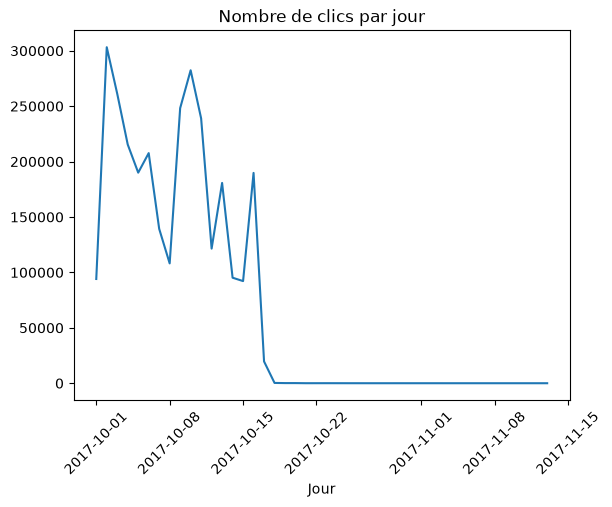

In [12]:
jours = pd.to_datetime(clicks["click_timestamp"], unit="ms").dt.date
jours.value_counts().sort_index().plot(title="Nombre de clics par jour", xlabel="Jour", rot=45)
plt.show()

## Nouveaux utilisateurs au fil des jours

Du 11 au 17 octobre, 14 % des clics viennent encore d'utilisateurs jamais vus


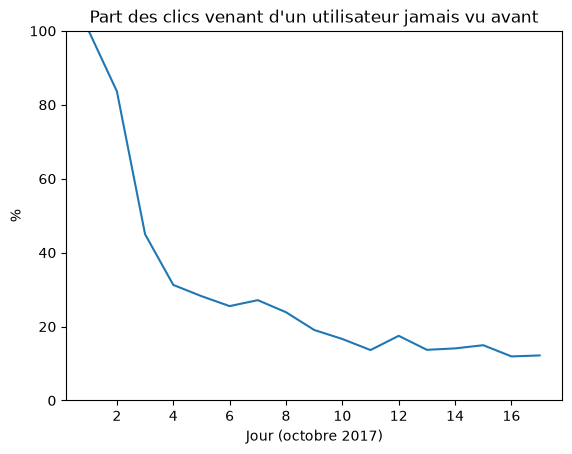

In [13]:
jour = pd.to_datetime(clicks["click_timestamp"], unit="ms").dt.normalize()
nouveau = jour == jour.groupby(clicks["user_id"]).transform("min")
part = 100 * nouveau.groupby(jour).mean().head(17)
part.index = part.index.day

print(f"Du 11 au 17 octobre, {part.tail(7).mean():.0f} % des clics viennent encore d'utilisateurs jamais vus")
part.plot(title="Part des clics venant d'un utilisateur jamais vu avant", ylim=(0, 100), ylabel="%", xlabel="Jour (octobre 2017)")
plt.show()

## Âge des articles au moment du clic

In [14]:
creation = clicks["click_article_id"].map(articles.set_index("article_id")["created_at_ts"])
age_heures = (clicks["click_timestamp"] - creation) / 3.6e6

print("Âge médian d'un article cliqué :", round(age_heures.median(), 1), "heures")
print(f"Articles cliqués moins de 24 h après publication : {(age_heures < 24).mean():.0%}")

Âge médian d'un article cliqué : 8.0 heures
Articles cliqués moins de 24 h après publication : 88%


## Durée de vie d'un article

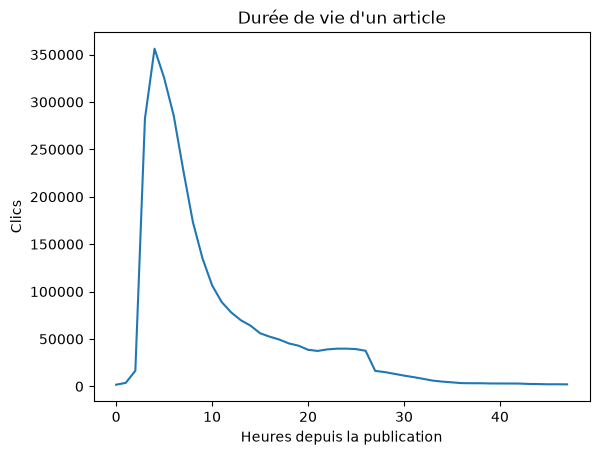

In [15]:
par_age = age_heures[age_heures.between(0, 48)].astype(int).value_counts().sort_index()

par_age.plot(title="Durée de vie d'un article", xlabel="Heures depuis la publication", ylabel="Clics")
plt.show()

## Nouveaux articles publiés chaque jour

788 nouveaux articles par jour, dont 99% cliqués au moins une fois


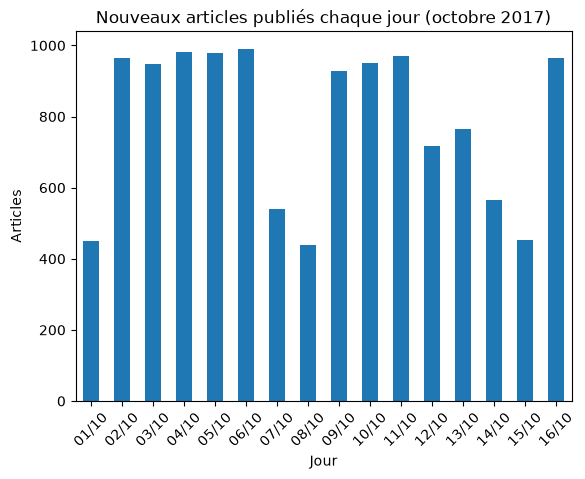

In [16]:
publication = pd.to_datetime(articles["created_at_ts"], unit="ms")
periode = (publication >= "2017-10-01") & (publication < "2017-10-17")
par_jour = publication[periode].dt.strftime("%d/%m").value_counts().sort_index()

print(f"{par_jour.mean():.0f} nouveaux articles par jour, dont {articles.loc[periode, 'article_id'].isin(clicks['click_article_id']).mean():.0%} cliqués au moins une fois")
par_jour.plot.bar(title="Nouveaux articles publiés chaque jour (octobre 2017)", xlabel="Jour", ylabel="Articles", rot=45)
plt.show()

## Conclusion

- On n'a que des clics, pas de notes ni de temps de lecture : les sessions sont courtes (2 à 3 clics, souvent espacés de 30 s exactement), donc on garde le clic seul (1 = lu).
- La matrice utilisateurs x articles est presque vide, et beaucoup d'utilisateurs ont très peu de clics : le filtrage collaboratif va avoir du mal.
- Longue traîne : environ 2 % des articles cliqués font 80 % des clics.
- Les clics s'arrêtent presque tous mi-octobre 2017.
- Les gens lisent surtout des articles de quelques heures, et un article ne vit qu'environ une journée : la fraîcheur compte beaucoup.
- Le démarrage à froid est permanent : environ 790 nouveaux articles par jour, et encore 14 % des clics venant d'utilisateurs jamais vus après deux semaines. Il faut un repli sur la popularité récente.
- Les embeddings rangent bien les articles par sujet (amas nets par catégorie sur le t-SNE), et la PCA à 50 dimensions garde 94,5 % de la variance : on peut réduire pour tenir sur Azure gratuit.